In [ ]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
# Load the CarDekho dataset

df = pd.read_csv("car data.csv")

# Display the first 5 rows
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [ ]:
# Check dataset shape and information

print("Dataset Shape:", df.shape)

print("\nDataset Information:")
df.info()

Dataset Shape: (301, 9)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [ ]:
# Check for duplicate rows
print("Number of duplicate rows:", df.duplicated().sum())

# Display basic statistical summary
print("\nStatistical Summary:")
df.describe()

Number of duplicate rows: 2

Statistical Summary:


,Year,Selling_Price,Present_Price,Kms_Driven,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.644115,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


In [ ]:
# Remove duplicate rows

print("Rows before removing duplicates:", df.shape[0])

df = df.drop_duplicates().reset_index(drop=True)

print("Rows after removing duplicates:", df.shape[0])
print("Duplicates remaining:", df.duplicated().sum())

Rows before removing duplicates: 301
Rows after removing duplicates: 299
Duplicates remaining: 0


In [ ]:
# Feature Engineering

# Calculate the age of each car
df["Car_Age"] = 2019 - df["Year"]

# Extract the car brand from the car name
df["Brand"] = df["Car_Name"].str.split().str[0]

# Display the new features
df[["Car_Name", "Year", "Car_Age", "Brand"]].head(10)

,Car_Name,Year,Car_Age,Brand
0,ritz,2014,5,ritz
1,sx4,2013,6,sx4
2,ciaz,2017,2,ciaz
3,wagon r,2011,8,wagon
4,swift,2014,5,swift
5,vitara brezza,2018,1,vitara
6,ciaz,2015,4,ciaz
7,s cross,2015,4,s
8,ciaz,2016,3,ciaz
9,ciaz,2015,4,ciaz


In [ ]:
# Clean the Brand feature

df["Brand"] = df["Brand"].replace({
    "s": "s-cross"
})

# Check the most common brands/model families
print(df["Brand"].value_counts().head(15))

Brand
city        26
Bajaj       25
corolla     17
Royal       17
Honda       17
Hero        15
verna       14
etios       11
fortuner    10
brio        10
ciaz         9
innova       9
i20          9
grand        8
Yamaha       8
Name: count, dtype: int64


In [ ]:
# Check unique values in categorical columns

print("Fuel Types:")
print(df["Fuel_Type"].value_counts())

print("\nSeller Types:")
print(df["Seller_Type"].value_counts())

print("\nTransmission Types:")
print(df["Transmission"].value_counts())

print("\nNumber of unique brands/model families:", df["Brand"].nunique())

Fuel Types:
Fuel_Type
Petrol    239
Diesel     58
CNG         2
Name: count, dtype: int64

Seller Types:
Seller_Type
Dealer        193
Individual    106
Name: count, dtype: int64

Transmission Types:
Transmission
Manual       260
Automatic     39
Name: count, dtype: int64

Number of unique brands/model families: 44


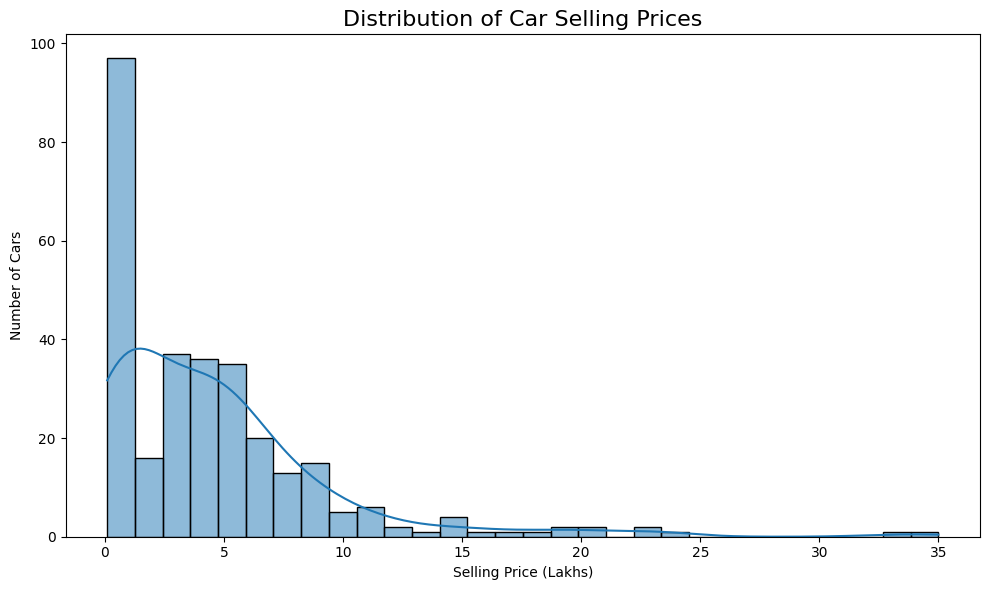

In [ ]:
# Distribution of Selling Price

plt.figure(figsize=(10, 6))

sns.histplot(df["Selling_Price"], bins=30, kde=True)

plt.title("Distribution of Car Selling Prices", fontsize=16)
plt.xlabel("Selling Price (Lakhs)")
plt.ylabel("Number of Cars")
plt.tight_layout()
plt.show()

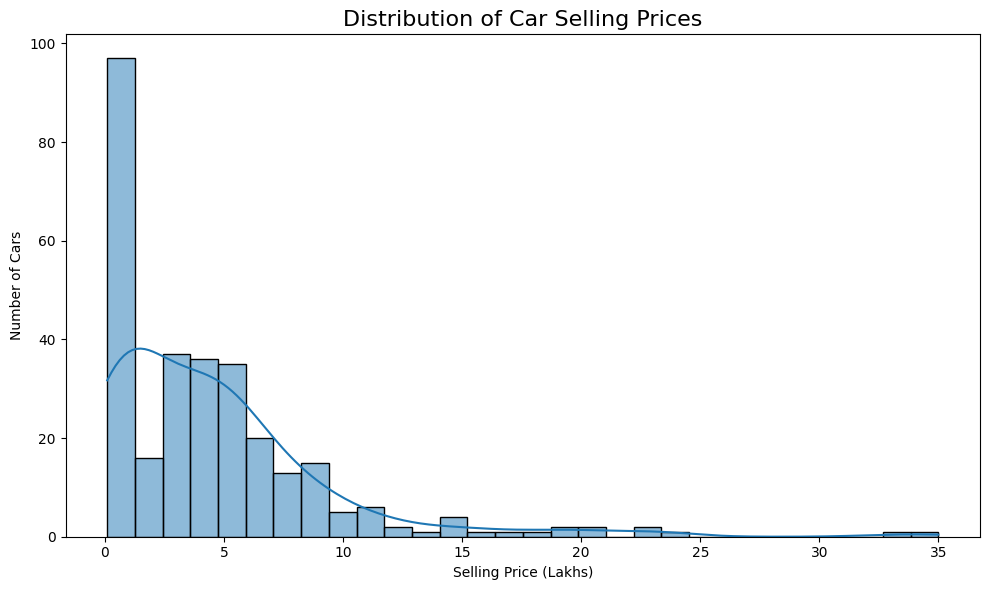

In [ ]:
# Distribution of Selling Price

plt.figure(figsize=(10, 6))

sns.histplot(df["Selling_Price"], bins=30, kde=True)

plt.title("Distribution of Car Selling Prices", fontsize=16)
plt.xlabel("Selling Price (Lakhs)")
plt.ylabel("Number of Cars")
plt.tight_layout()
plt.show()

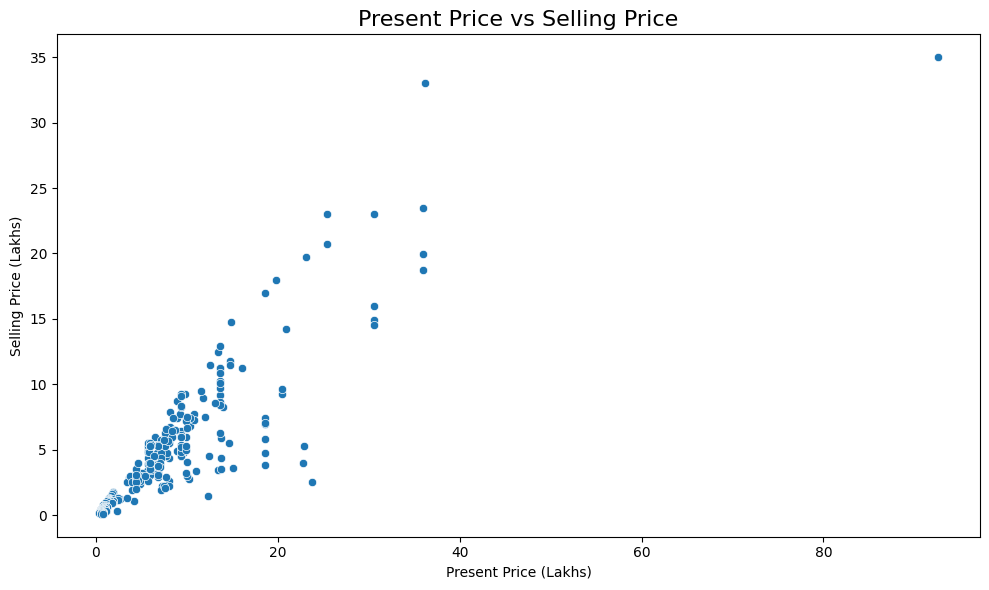

In [12]:
# Relationship between Present Price and Selling Price

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="Present_Price",
    y="Selling_Price"
)

plt.title("Present Price vs Selling Price", fontsize=16)
plt.xlabel("Present Price (Lakhs)")
plt.ylabel("Selling Price (Lakhs)")
plt.tight_layout()
plt.show()

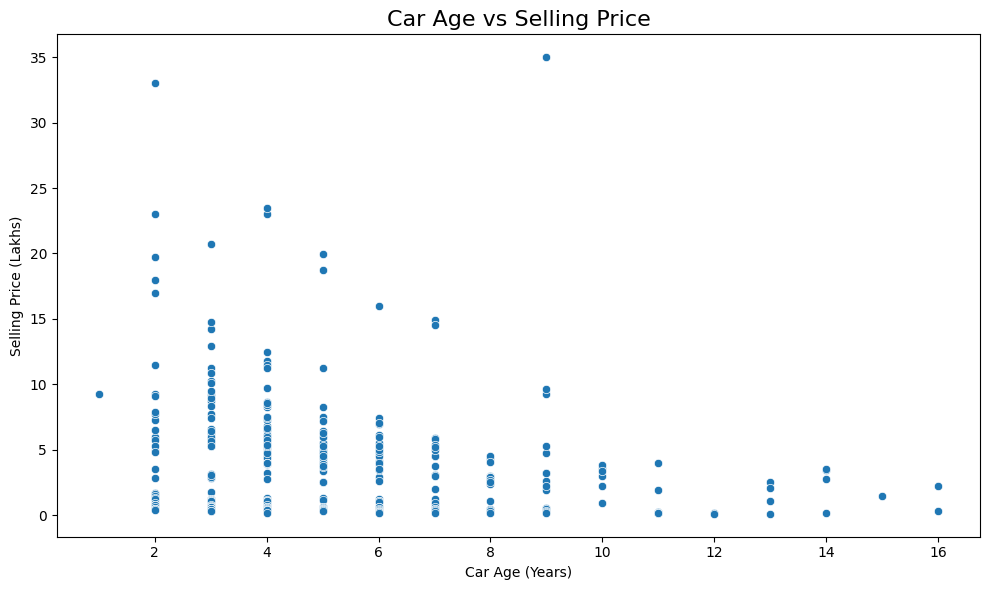

In [13]:
# Relationship between Car Age and Selling Price

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="Car_Age",
    y="Selling_Price"
)

plt.title("Car Age vs Selling Price", fontsize=16)
plt.xlabel("Car Age (Years)")
plt.ylabel("Selling Price (Lakhs)")
plt.tight_layout()
plt.show()

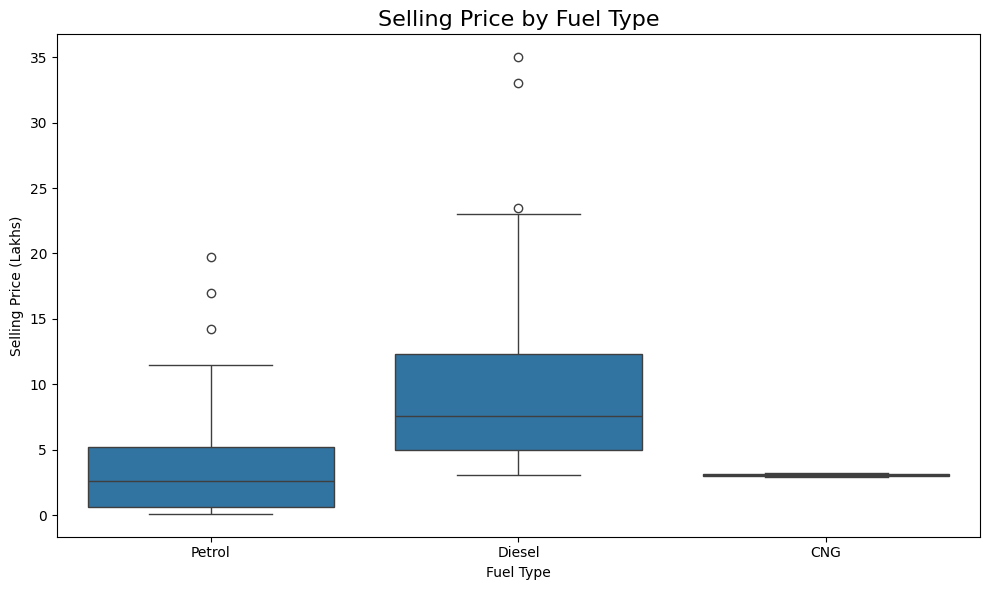

In [14]:
# Selling Price by Fuel Type

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="Fuel_Type",
    y="Selling_Price"
)

plt.title("Selling Price by Fuel Type", fontsize=16)
plt.xlabel("Fuel Type")
plt.ylabel("Selling Price (Lakhs)")
plt.tight_layout()
plt.show()

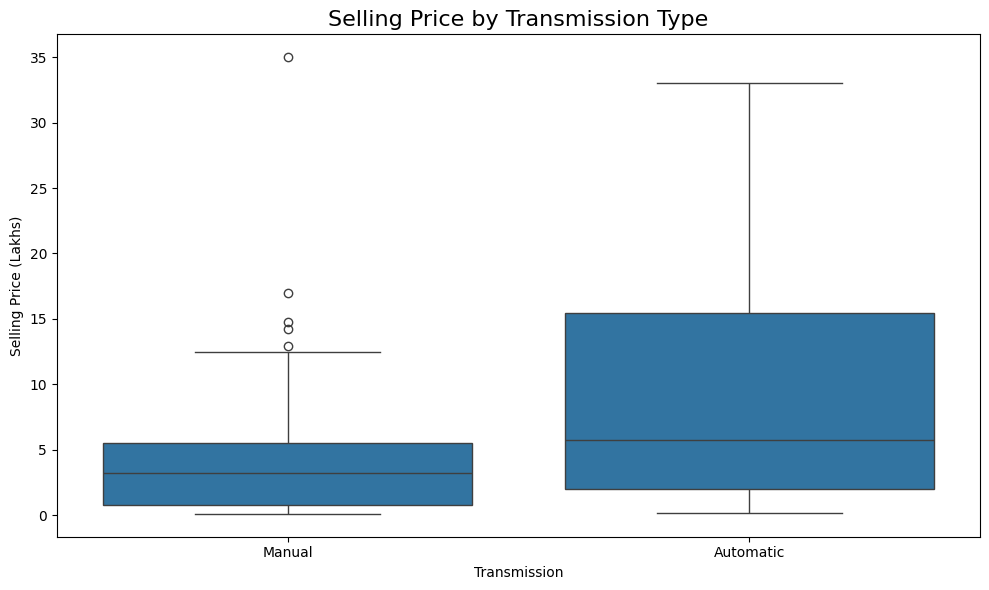

In [15]:
# Selling Price by Transmission Type

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="Transmission",
    y="Selling_Price"
)

plt.title("Selling Price by Transmission Type", fontsize=16)
plt.xlabel("Transmission")
plt.ylabel("Selling Price (Lakhs)")
plt.tight_layout()
plt.show()

In [16]:
# Calculate depreciation percentage

df["Depreciation_Percentage"] = (
    (df["Present_Price"] - df["Selling_Price"])
    / df["Present_Price"]
) * 100

# View the result

df[[
    "Car_Name",
    "Present_Price",
    "Selling_Price",
    "Depreciation_Percentage"
]].head(10)

,Car_Name,Present_Price,Selling_Price,Depreciation_Percentage
0,ritz,5.59,3.35,40.071556
1,sx4,9.54,4.75,50.209644
2,ciaz,9.85,7.25,26.395939
3,wagon r,4.15,2.85,31.325301
4,swift,6.87,4.60,33.042213
5,vitara brezza,9.83,9.25,5.900305
6,ciaz,8.12,6.75,16.871921
7,s cross,8.61,6.50,24.506388
8,ciaz,8.89,8.75,1.574803
9,ciaz,8.92,7.45,16.479821


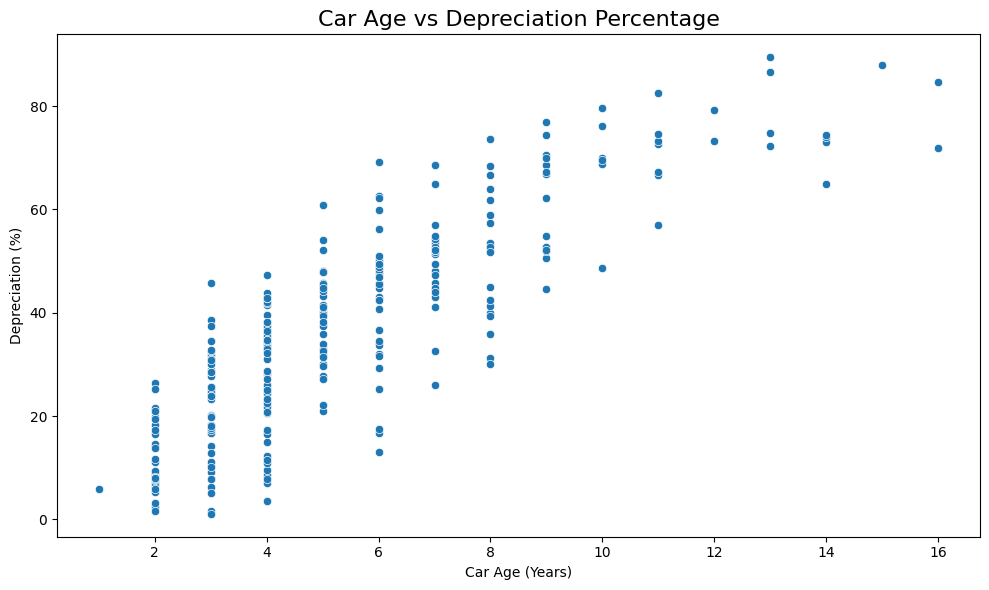

In [17]:
# Depreciation Percentage vs Car Age

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="Car_Age",
    y="Depreciation_Percentage"
)

plt.title("Car Age vs Depreciation Percentage", fontsize=16)
plt.xlabel("Car Age (Years)")
plt.ylabel("Depreciation (%)")
plt.tight_layout()
plt.show()

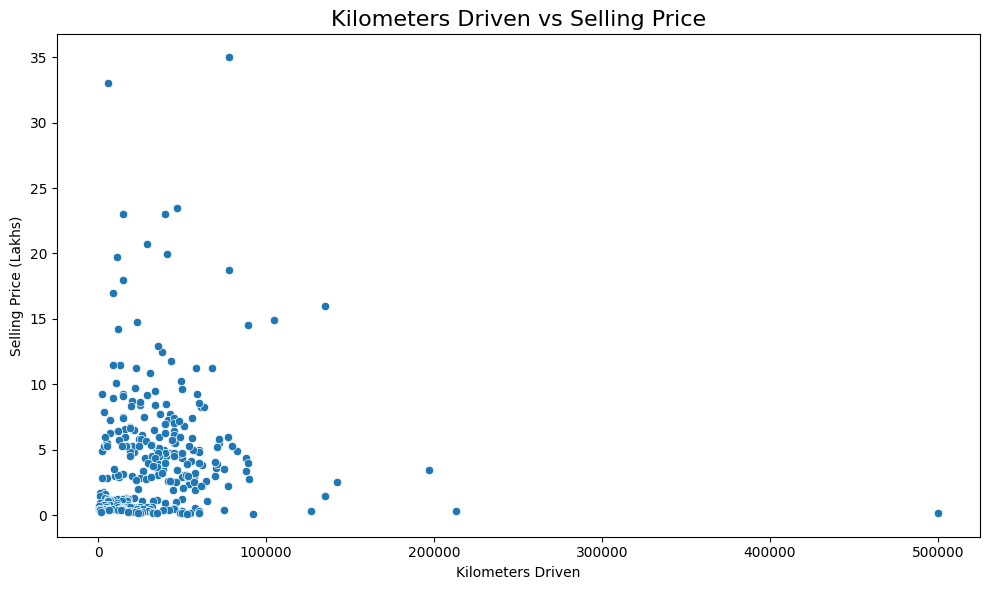

In [18]:
# Relationship between Kilometers Driven and Selling Price

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="Kms_Driven",
    y="Selling_Price"
)

plt.title("Kilometers Driven vs Selling Price", fontsize=16)
plt.xlabel("Kilometers Driven")
plt.ylabel("Selling Price (Lakhs)")
plt.tight_layout()
plt.show()

Insight: Higher mileage is generally associated with lower resale prices. Most vehicles in the dataset have been driven below 100,000 km, while cars priced above ₹15 lakh are concentrated at relatively lower mileage levels. Beyond 100,000 km, most vehicles fall below ₹5 lakh in selling price. A few high-mileage vehicles between 150,000 and 220,000 km have very low resale values, while the 500,000 km observation represents an extreme high-mileage, low-price case.


In [19]:
# Step 13: Value Retention by Car Model Family

model_value = (
    df.groupby("Car_Name")
      .agg(
          Cars=("Car_Name", "count"),
          Avg_Depreciation=("Depreciation_Percentage", "mean"),
          Avg_Selling_Price=("Selling_Price", "mean")
      )
      .reset_index()
)

# Keep model families with at least 3 cars
model_value_filtered = model_value[model_value["Cars"] >= 3]

# Select the 10 models with the lowest average depreciation
top_value_retention = (
    model_value_filtered
    .sort_values("Avg_Depreciation")
    .head(10)
)

top_value_retention

,Car_Name,Cars,Avg_Depreciation,Avg_Selling_Price
72,creta,3,13.235294,11.800000
82,grand i10,8,13.267544,4.943750
6,Bajaj Avenger 220,3,16.842105,0.790000
32,Honda CB Hornet 160R,3,17.624521,0.716667
66,brio,10,21.746245,4.745000
46,Royal Enfield Classic 350,7,22.157434,1.144286
68,ciaz,9,22.487716,7.472222
48,Royal Enfield Thunder 350,4,22.500000,1.162500
60,Yamaha FZ S V 2.0,3,28.174603,0.603333
92,swift,5,28.737093,4.540000


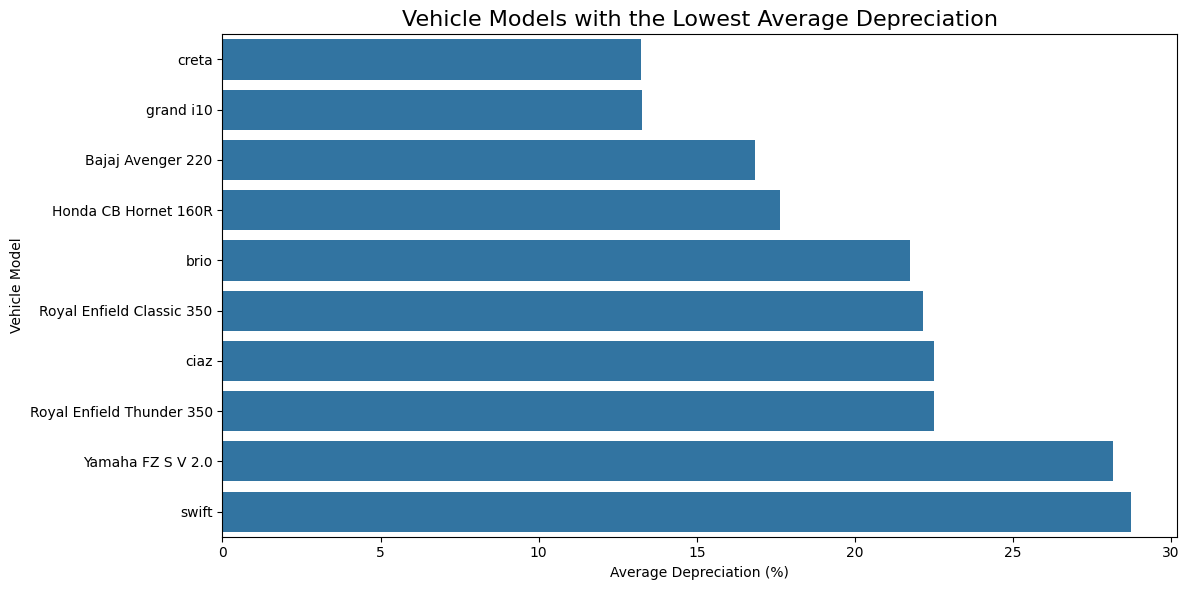

In [20]:
# Step 13A: Top Vehicle Models by Value Retention

plt.figure(figsize=(12, 6))

sns.barplot(
    data=top_value_retention,
    x="Avg_Depreciation",
    y="Car_Name"
)

plt.title("Vehicle Models with the Lowest Average Depreciation", fontsize=16)
plt.xlabel("Average Depreciation (%)")
plt.ylabel("Vehicle Model")
plt.tight_layout()
plt.show()

Insight: Among vehicle models with at least 3 observations, Creta and Grand i10 show the lowest average depreciation at around 13.2%, indicating strong value retention in this dataset. Several motorcycles also appear among the top value-retaining vehicles, while Brio, Ciaz, and Swift show relatively lower depreciation among the passenger cars in this group. The variation across models suggests that resale value is influenced by vehicle-specific factors in addition to age and mileage.

In [21]:
# Step 14: Correlation Analysis

numeric_columns = [
    "Year",
    "Selling_Price",
    "Present_Price",
    "Kms_Driven",
    "Owner",
    "Car_Age",
    "Depreciation_Percentage"
]

correlation_matrix = df[numeric_columns].corr()

correlation_matrix

,Year,Selling_Price,Present_Price,Kms_Driven,Owner,Car_Age,Depreciation_Percentage
Year,1.000000,0.234369,-0.053563,-0.525714,-0.181639,-1.000000,-0.848636
Selling_Price,0.234369,1.000000,0.876378,0.028566,-0.087880,-0.234369,-0.230115
Present_Price,-0.053563,0.876378,1.000000,0.205253,0.009947,0.053563,0.109518
Kms_Driven,-0.525714,0.028566,0.205253,1.000000,0.089367,0.525714,0.506720
Owner,-0.181639,-0.087880,0.009947,0.089367,1.000000,0.181639,0.222203
Car_Age,-1.000000,-0.234369,0.053563,0.525714,0.181639,1.000000,0.848636
Depreciation_Percentage,-0.848636,-0.230115,0.109518,0.506720,0.222203,0.848636,1.000000


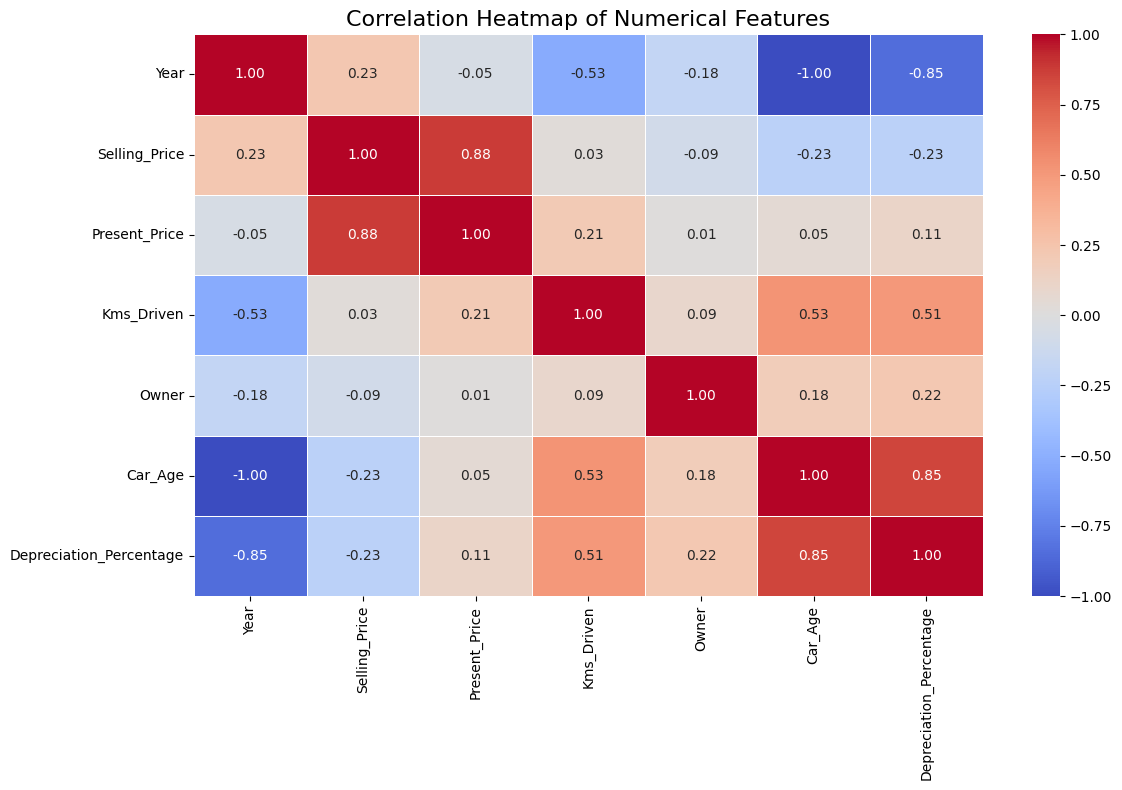

In [22]:
# Step 14A: Correlation Heatmap

plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap of Numerical Features", fontsize=16)
plt.tight_layout()
plt.show()

Key Insights: Present Price has the strongest positive relationship with Selling Price (0.88), indicating that vehicles with higher present prices generally have higher resale prices. Car Age has a strong positive relationship with Depreciation Percentage (0.85), showing that older vehicles generally experience greater value loss. Car Age and Kms Driven have a moderate positive relationship (0.53), suggesting that older vehicles tend to accumulate more mileage. Selling Price and Kms Driven have almost no linear relationship (0.03) in this dataset, indicating that mileage alone does not explain resale price. Owner count also has a weak relationship with Selling Price (-0.09). These results show that resale pricing depends on multiple vehicle characteristics rather than a single numerical factor.

In [23]:
# Step 15: Prepare Features and Target

# Selling_Price is the target variable
y = df["Selling_Price"]

# Select features for machine learning
X = df[
    [
        "Present_Price",
        "Kms_Driven",
        "Car_Age",
        "Owner",
        "Brand",
        "Fuel_Type",
        "Seller_Type",
        "Transmission"
    ]
]

print("Features selected:")
print(X.columns.tolist())

print("\nTarget variable:")
print(y.name)

print("\nFeature dataset shape:", X.shape)
print("Target shape:", y.shape)

Features selected:
['Present_Price', 'Kms_Driven', 'Car_Age', 'Owner', 'Brand', 'Fuel_Type', 'Seller_Type', 'Transmission']

Target variable:
Selling_Price

Feature dataset shape: (299, 8)
Target shape: (299,)


In [24]:
# Step 15.2: Identify Numerical and Categorical Features

numerical_features = [
    "Present_Price",
    "Kms_Driven",
    "Car_Age",
    "Owner"
]

categorical_features = [
    "Brand",
    "Fuel_Type",
    "Seller_Type",
    "Transmission"
]

print("Numerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['Present_Price', 'Kms_Driven', 'Car_Age', 'Owner']

Categorical features:
['Brand', 'Fuel_Type', 'Seller_Type', 'Transmission']


In [25]:
# Step 15.3: Encode Categorical Features

preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numerical_features),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)

print("Preprocessor created successfully!")

Preprocessor created successfully!


In [26]:
# Step 15.4: Split Data into Training and Testing Sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training feature shape:", X_train.shape)
print("Testing feature shape:", X_test.shape)
print("Training target shape:", y_train.shape)
print("Testing target shape:", y_test.shape)

Training feature shape: (239, 8)
Testing feature shape: (60, 8)
Training target shape: (239,)
Testing target shape: (60,)


In [27]:
# Step 16: Linear Regression Model

linear_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

# Train the model
linear_model.fit(X_train, y_train)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


In [28]:
# Step 16.1: Evaluate Linear Regression

# Make predictions on the test data
y_pred_linear = linear_model.predict(X_test)

# Calculate evaluation metrics
mae_linear = mean_absolute_error(y_test, y_pred_linear)
rmse_linear = np.sqrt(mean_squared_error(y_test, y_pred_linear))
r2_linear = r2_score(y_test, y_pred_linear)

print("Linear Regression Performance")
print("-" * 35)
print(f"MAE  : {mae_linear:.3f}")
print(f"RMSE : {rmse_linear:.3f}")
print(f"R²   : {r2_linear:.3f}")

Linear Regression Performance
-----------------------------------
MAE  : 1.348
RMSE : 2.389
R²   : 0.779


In [29]:
# Step 16.2: Random Forest Regression Model

random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestRegressor(
                n_estimators=300,
                random_state=42
            )
        )
    ]
)

# Train the model
random_forest_model.fit(X_train, y_train)

print("Random Forest Regression model trained successfully!")

Random Forest Regression model trained successfully!


In [30]:
# Step 16.3: Evaluate Random Forest Regression

# Make predictions on the test data
y_pred_rf = random_forest_model.predict(X_test)

# Calculate evaluation metrics
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Regression Performance")
print("-" * 40)
print(f"MAE  : {mae_rf:.3f}")
print(f"RMSE : {rmse_rf:.3f}")
print(f"R²   : {r2_rf:.3f}")

Random Forest Regression Performance
----------------------------------------
MAE  : 1.353
RMSE : 3.241
R²   : 0.592


In [31]:
# Step 17: Compare Model Performance

model_comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest"
    ],
    "MAE": [
        mae_linear,
        mae_rf
    ],
    "RMSE": [
        rmse_linear,
        rmse_rf
    ],
    "R2": [
        r2_linear,
        r2_rf
    ]
})

model_comparison

,Model,MAE,RMSE,R2
0,Linear Regression,1.348138,2.388979,0.77856
1,Random Forest,1.352827,3.241487,0.59232


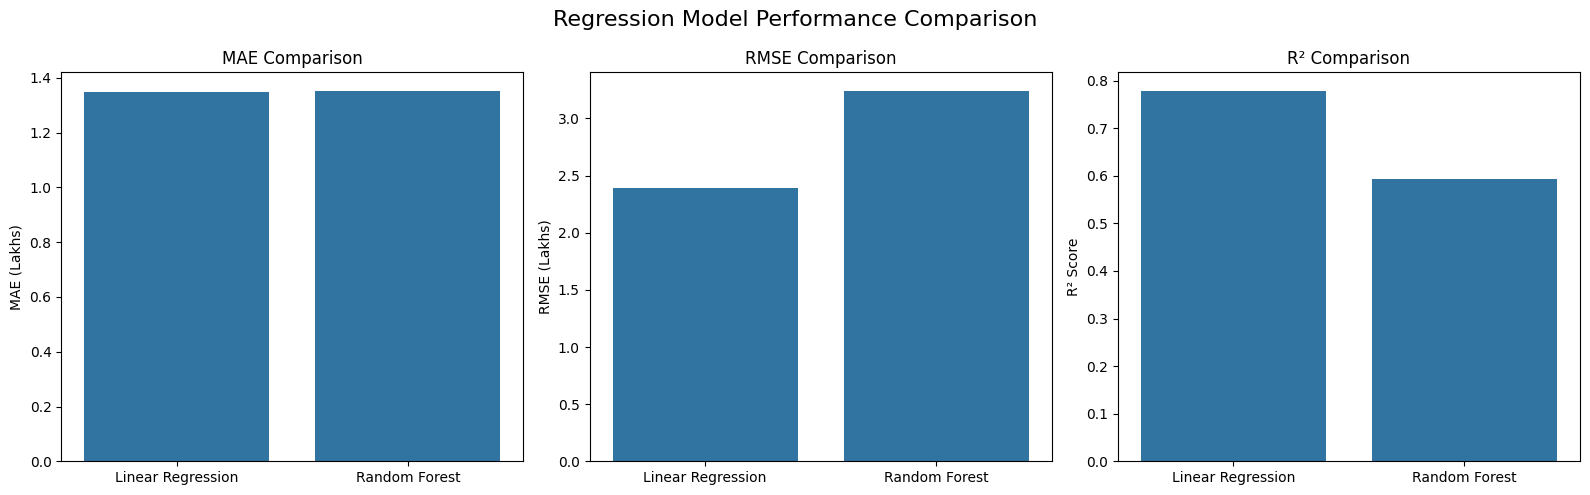

In [32]:
# Step 17.1: Visual Comparison of Model Performance

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# MAE
sns.barplot(data=model_comparison, x="Model", y="MAE", ax=axes[0])
axes[0].set_title("MAE Comparison")
axes[0].set_xlabel("")
axes[0].set_ylabel("MAE (Lakhs)")

# RMSE
sns.barplot(data=model_comparison, x="Model", y="RMSE", ax=axes[1])
axes[1].set_title("RMSE Comparison")
axes[1].set_xlabel("")
axes[1].set_ylabel("RMSE (Lakhs)")

# R²
sns.barplot(data=model_comparison, x="Model", y="R2", ax=axes[2])
axes[2].set_title("R² Comparison")
axes[2].set_xlabel("")
axes[2].set_ylabel("R² Score")

plt.suptitle("Regression Model Performance Comparison", fontsize=16)
plt.tight_layout()
plt.show()

Key Insight: Linear Regression performed better than Random Forest on the test set across all three evaluation metrics. It achieved a slightly lower MAE (1.348 vs. 1.353 lakhs), a lower RMSE (2.389 vs. 3.241 lakhs), and a higher R² score (0.779 vs. 0.592). This means Linear Regression explained approximately 77.9% of the variation in selling prices on the test data, compared with 59.2% for Random Forest. Based on these test-set results, Linear Regression provides the stronger predictive performance for this dataset.

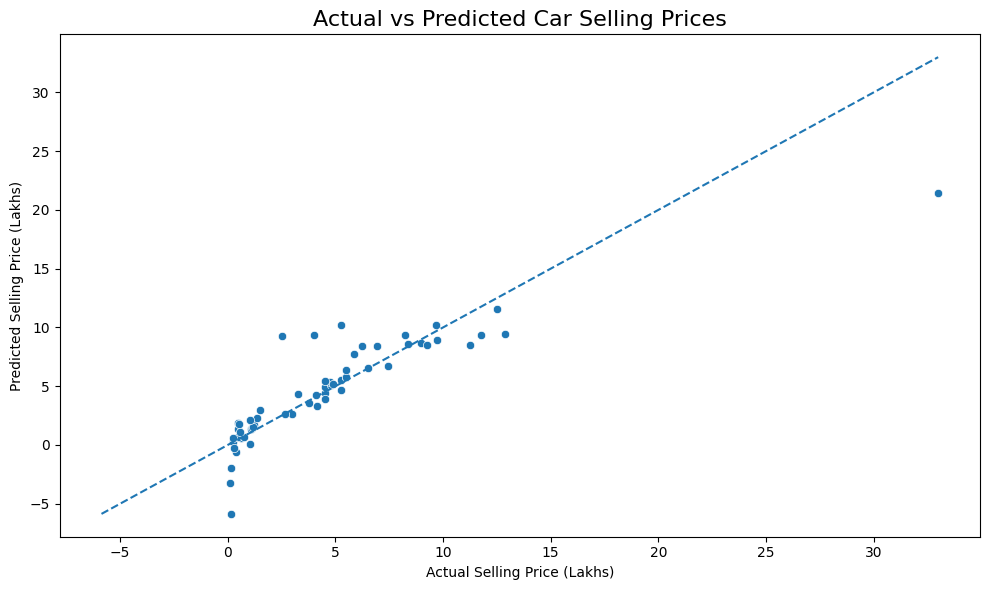

In [33]:
# Step 18: Actual vs Predicted Selling Prices

plt.figure(figsize=(10, 6))

sns.scatterplot(
    x=y_test,
    y=y_pred_linear
)

# Perfect prediction reference line
min_price = min(y_test.min(), y_pred_linear.min())
max_price = max(y_test.max(), y_pred_linear.max())

plt.plot(
    [min_price, max_price],
    [min_price, max_price],
    linestyle="--"
)

plt.title("Actual vs Predicted Car Selling Prices", fontsize=16)
plt.xlabel("Actual Selling Price (Lakhs)")
plt.ylabel("Predicted Selling Price (Lakhs)")
plt.tight_layout()
plt.show()

Key Insights: The Actual vs Predicted plot shows how closely the Linear Regression model's predictions follow the ideal prediction line. Most observations are concentrated around the reference line, particularly for cars in the lower-to-mid selling-price range, indicating that the model captures the general pricing pattern reasonably well. Some larger deviations are visible for high-value vehicles, showing that the model has greater difficulty predicting extreme prices. A few predictions also fall below zero for very low-value cars, highlighting a limitation of unconstrained Linear Regression. Overall, the visualization is consistent with the model's test-set R² of 0.779, while also showing where prediction errors are more noticeable.

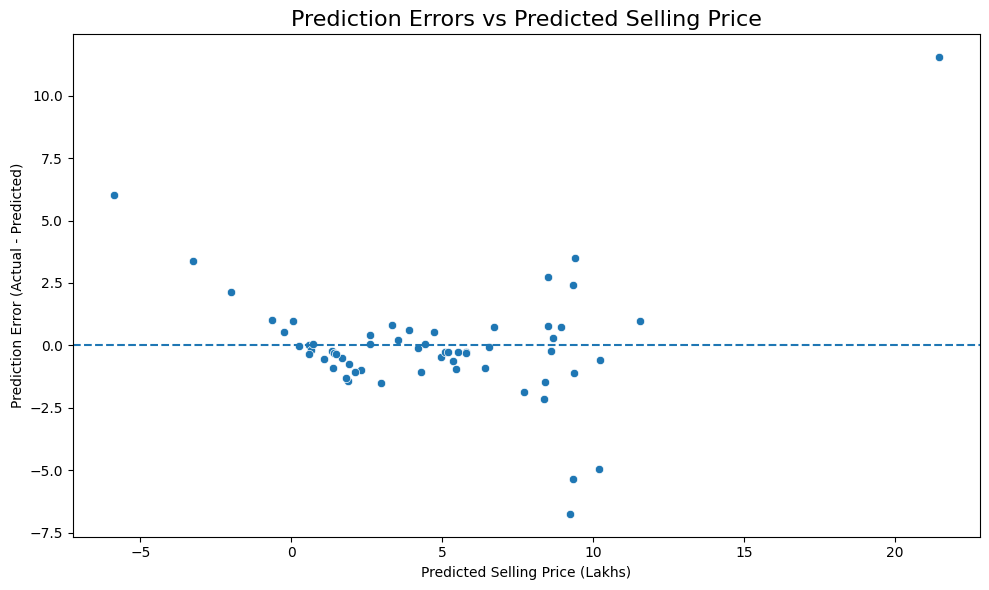

In [34]:
# Step 18.1: Prediction Error Analysis

prediction_errors = y_test - y_pred_linear

plt.figure(figsize=(10, 6))

sns.scatterplot(
    x=y_pred_linear,
    y=prediction_errors
)

plt.axhline(0, linestyle="--")

plt.title("Prediction Errors vs Predicted Selling Price", fontsize=16)
plt.xlabel("Predicted Selling Price (Lakhs)")
plt.ylabel("Prediction Error (Actual - Predicted)")
plt.tight_layout()
plt.show()

Key Insights: The residual plot shows the difference between actual and predicted selling prices across the range of predicted prices. The dashed horizontal line at 0 represents zero prediction error. Points above the line indicate underprediction, while points below the line indicate overprediction.

Most residuals are concentrated around zero for predicted prices in the lower-to-mid range, indicating that the model captures the general pricing pattern reasonably well for many vehicles. However, the spread of residuals becomes wider at higher predicted prices, suggesting that prediction errors are not equally distributed across the entire price range.

The negative predicted prices visible at the lower end are a limitation of unconstrained Linear Regression, since actual car prices cannot be negative. At the high-value end, some vehicles show large positive residuals, indicating substantial underprediction of expensive cars.

Overall, the residual plot suggests that Linear Regression performs reasonably well for many lower- and mid-priced vehicles but has larger errors at the extreme ends of the price range. The pattern also suggests that the relationship between the features and selling price may not be completely linear.

In [35]:
# Step 19: Feature Importance from Random Forest

# Get the fitted preprocessing and Random Forest model
rf_preprocessor = random_forest_model.named_steps["preprocessor"]
rf_model = random_forest_model.named_steps["model"]

# Get feature names after one-hot encoding
feature_names = rf_preprocessor.get_feature_names_out()

# Get Random Forest feature importance values
importances = rf_model.feature_importances_

# Create feature importance table
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values("Importance", ascending=False)

# Display top 10 features
feature_importance.head(10)

,Feature,Importance
0,num__Present_Price,0.886130
2,num__Car_Age,0.065694
35,cat__Brand_land,0.018222
1,num__Kms_Driven,0.012132
48,cat__Transmission_Automatic,0.003050
49,cat__Transmission_Manual,0.002705
21,cat__Brand_corolla,0.002496
47,cat__Seller_Type_Individual,0.001690
33,cat__Brand_innova,0.001566
46,cat__Seller_Type_Dealer,0.001042


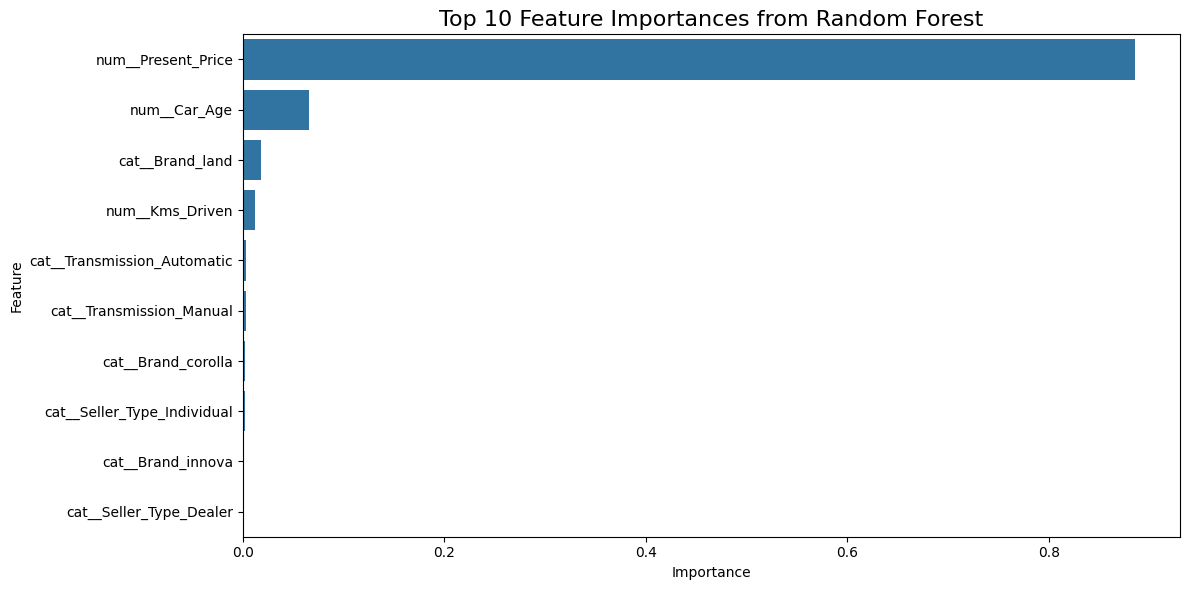

In [36]:
# Step 19.1: Top 10 Random Forest Feature Importances

top_features = feature_importance.head(10)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Feature Importances from Random Forest", fontsize=16)
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

Key Insights: The Random Forest feature-importance analysis shows that Present_Price has the largest contribution to the model's predictions, with an importance of approximately 0.886. Car_Age is the second most important feature at approximately 0.066. Other individual features, including derived brand categories and Kms_Driven, have considerably smaller importance values.

This indicates that the Random Forest model relies heavily on the vehicle's present price and age when estimating selling price, while the remaining features provide smaller additional contributions. However, these importance values describe how the Random Forest model uses the available features and should not be interpreted as causal effects or as proof that one feature independently determines resale value.

In [37]:
# Step 20: Sample Car Price Predictions

sample_cars = X_test.head(5).copy()

sample_predictions = linear_model.predict(sample_cars)

prediction_results = sample_cars.copy()
prediction_results["Actual_Selling_Price"] = y_test.loc[sample_cars.index].values
prediction_results["Predicted_Selling_Price"] = sample_predictions

prediction_results[
    [
        "Present_Price",
        "Kms_Driven",
        "Car_Age",
        "Owner",
        "Actual_Selling_Price",
        "Predicted_Selling_Price"
    ]
]

,Present_Price,Kms_Driven,Car_Age,Owner,Actual_Selling_Price,Predicted_Selling_Price
281,11.80,9010,3,0,8.99,8.681577
265,9.40,19434,3,0,8.35,8.591650
164,0.55,1000,3,0,0.45,1.867017
9,8.92,42367,4,0,7.45,6.708138
77,22.83,80000,9,0,5.25,10.197704


### Final Model Summary

Two regression models were trained and evaluated for car selling-price prediction: Linear Regression and Random Forest Regression.

| Model             |   MAE |  RMSE |    R² |
| ----------------- | ----: | ----: | ----: |
| Linear Regression | 1.348 | 2.389 | 0.779 |
| Random Forest     | 1.353 | 3.241 | 0.592 |

On the test set, Linear Regression produced the lower MAE and RMSE and the higher R² score. Its R² of 0.779 indicates that the model explained approximately 77.9% of the variation in selling prices in this particular test set.

The results also show that prediction accuracy varies across the price range. The model generally follows the pricing pattern for many lower- and mid-priced vehicles but has larger errors for some high-value and extreme observations.

Based on these test-set results, **Linear Regression was selected as the final model for this project**.


## Final Conclusion

This project developed a machine learning approach for predicting used-car selling prices using the CarDekho vehicle dataset.

The dataset was cleaned by removing duplicate records, resulting in 299 observations. Feature engineering was performed by creating `Car_Age` and a derived `Brand` category from the car-name field. Exploratory analysis showed a strong positive relationship between `Present_Price` and `Selling_Price`, while vehicle age was associated with greater depreciation.

Two regression models were evaluated: Linear Regression and Random Forest Regression. On the test set, Linear Regression achieved an MAE of 1.348 lakhs, RMSE of 2.389 lakhs, and R² of 0.779, while Random Forest achieved an MAE of 1.353 lakhs, RMSE of 3.241 lakhs, and R² of 0.592. Based on these test-set results, Linear Regression was selected as the final model.

The feature-importance analysis from Random Forest showed that `Present_Price` had the largest model-specific importance, followed by `Car_Age`. This highlights the strong predictive role of vehicle pricing and age in the trained model.

## Limitations

* The dataset contains only 299 records after duplicate removal, so the results may not generalize to all used-car markets.
* The dataset contains some extreme high-value observations that contribute to larger prediction errors.
* The Linear Regression model produced some negative predictions at the very low end of the price range, which is not realistic for actual car prices.
* The derived `Brand` feature is based on the first token of `Car_Name` and should be treated as an approximate category rather than a verified manufacturer field.
* Model performance was evaluated on one train-test split, so additional validation could provide a more robust estimate of generalization performance.
* Correlation and feature-importance results describe statistical/model relationships and should not be interpreted as causal effects.

## Project Outcome

The project demonstrates a complete machine learning workflow covering data cleaning, feature engineering, exploratory data analysis, categorical encoding, model training, evaluation, prediction analysis, and feature-importance analysis.
